In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper


api_wrapper_arxiv = ArxivAPIWrapper(top_k_results = 2, doc_content_chars_max = 500)
arxiv = ArxivQueryRun(api_wrapper = api_wrapper_arxiv, description = "Query arxiv papers")
print(arxiv.name)


arxiv


In [2]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [3]:

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results = 2, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper = api_wrapper_wiki, description = "Query wiki papers")
print(wiki.name)

wikipedia


In [4]:
wiki.invoke("Quantum physics")

'Page: Quantum mechanics\nSummary: Quantum mechanics is the fundamental physical theory that describes the behavior of matter and of light; its unusual characteristics typically occur at and below the scale of atoms. It is the foundation of all quantum physics, which includes quantum chemistry, quantum biology, quantum field theory, quantum technology, and quantum information science.\nQuantum mechanics can describe many systems that classical physics cannot. Classical physics can describe many asp'

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ['TAVILY_API_KEY'] = os.getenv("TAVILY_API_KEY")


In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()
tavily.invoke("Provide me the recent AI news")

C:\Users\saikr\AppData\Local\Temp\ipykernel_29272\3648200869.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Source: AP News ↗\n\n### Palladyne AI Secures Major Defense Contract for Propulsion Subsystems\n\nDate: February 3, 2026\n\nSummary: Palladyne AI Corp. has announced it was awarded a contract by a major defense prime contractor to deliver a key propulsion subsystem. The project will leverage Palladyne\'s advanced AI-driven software to enhance the performance and reliability of complex propulsion systems. This contract highlights the growing demand for Palladyne’s ability to apply artificial intelligence to physical hardware in high-stakes environments, specifically in increasing the autonomous capabilities of defense infrastructure. The partnership is seen as a significant validation of the company\'s "software-first" approach to industrial and defense robotics.\n\nSource: Stock Titan ↗ [...] Date: January 29, 2026\n\nSummary

In [9]:
tools = [arxiv, wiki, tavily]


In [15]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("What is AI")

AIMessage(content="<think>\nOkay, the user is asking what AI is. Let me start by defining AI in simple terms. AI stands for Artificial Intelligence. But what does that really mean? I should explain it's about creating systems that can perform tasks requiring human intelligence. Maybe mention things like learning, problem-solving, understanding language.\n\nWait, the user might be new to this, so I need to keep it clear. Maybe start with the basic definition. Then break it down into subfields like machine learning, neural networks. Oh, and give examples of real-world applications like Siri, self-driving cars, recommendation systems. That could help them visualize it better.\n\nI should also differentiate AI from other terms like machine learning. Maybe clarify that ML is a subset of AI. Oh, and mention types of AI—narrow AI versus general AI. But be careful not to get too technical. The user might not need the differences right now unless they ask for more.\n\nApplications are important

In [12]:
llm_with_tools = llm.bind_tools(tools=tools)

In [13]:
llm_with_tools.invoke("What is the recent news on AI")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. Let me see which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for academic papers, so maybe not the best choice for recent news. Wikipedia might have some information, but it\'s more of an encyclopedia and might not have the latest updates. The third option is tavily_search_results_json, which is described as a search engine optimized for current events. That sounds perfect for this query. \n\nI need to make sure the input is a search query. The user\'s question is straightforward, so the query should be something like "recent news on AI". Let me format the tool call correctly. The function name is tavily_search_results_json and the argument is the query. I\'ll structure the JSON accordingly.\n', 'tool_calls': [{'id': 'ahg0c2zdn', 'function': {'arguments': '{"query":"recent news on AI"}', 'name': 'tavily_search_results

### Workflow

In [25]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage,HumanMessage #Human message or AI message
from typing import Annotated
from langgraph.graph.message import add_messages #Reducers in Langgraph

In [18]:
class State(TypedDict):
    #list of messages like AI and human messages
    messages : Annotated[list[AnyMessage], add_messages] # Append messages in the variable, will not override



In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition



In [23]:
def tool_calling_llm(state:State):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }
builder = StateGraph(State)
builder.add_node("tools_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",
    # if the latesr message (result) from assistant is a tool call -> tool_conditon routes to tools
    # if the latesr message (result) from assistant is not a tool call -> tool_conditon routes to END
    tools_condition
)
builder.add_edge("tools", END)


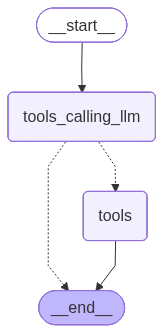

In [24]:
# compile the graph

graph_builder = builder.compile()


display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [27]:
messages = graph_builder.invoke({"messages": "1706.03762"})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (w9d7q7jcz)
 Call ID: w9d7q7jcz
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
